In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import datetime
import itertools

import matplotlib.dates as mdates
import numpy.ma as ma
import CRPS.CRPS as pscore
from torch.utils.data import Dataset
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.image as mpimg
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.model_selection import KFold
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader
import pickle as pkl
from pathlib import Path
import os

In [8]:
current_file = Path(os.getcwd()).resolve()

project_root = current_file.parent.parent.parent

In [9]:
import pandas as pd

# Load metadata.parquet file
metadata_df = pd.read_parquet(f"{project_root}/PVOutputPrediction/preprocessing/data/data_forecast4/metadata_test/metadata.parquet")

In [10]:
times_test = metadata_df.time.to_numpy()

In [11]:
project_root

PosixPath('/home/ubuntu')

In [12]:
pv_log_test = metadata_df.pv_pred.to_numpy()
prediction_ensemble= np.load(os.path.join(project_root,"PVOutputPrediction/preprocessing/data/data_forecast4/predictions_uoh_pretrained.npy"))

In [ ]:
#pv_log_test = metadata_df.pv_pred.to_numpy()
#prediction_ensemble= np.load(os.path.join(project_root,"PVOutputPrediction/preprocessing/data/data_forecast4/predictions_cloudy_finetune.npy"))

In [13]:
# formulate sunny and cloudy test days
sunny_dates = [] # you can put sunny days here if you want to test sunny condition performance
#cloudy_dates = [(2017,9,6),(2017,11,4),(2017,12,29), (2018,5,31),(2018,7,12),(2018,10,3), (2019,1,26),(2019,5,27),(2019,9,7),(2019,10,19)]
cloudy_dates = [(2017,6,24),(2017,9,20),(2017,10,11),(2018,1,25),(2018,3,9),(2018,10,4),(2019,5,27),(2019,6,28),(2019,8,10),(2019,10,19)]
sunny_dates_test = [datetime.date(day[0],day[1],day[2]) for day in sunny_dates]
cloudy_dates_test = [datetime.date(day[0],day[1],day[2]) for day in cloudy_dates]

dates_test = np.asarray(pd.to_datetime(times_test).date)

## generate mask for the sunny days
mask = np.zeros(len(pv_log_test),dtype=bool)
for i in sunny_dates_test:
    mask[np.where(dates_test==i)[0]]=1

## apply the mask to the dataset
times_test_sunny = times_test[mask]
pv_log_test_sunny = pv_log_test[mask]
#images_log_test_sunny = images_log_test[mask]
prediction_ensemble_sunny = prediction_ensemble[mask]
print("times_test_sunny.shape:",times_test_sunny.shape)

times_test_cloudy = times_test[~mask]
pv_log_test_cloudy = pv_log_test[~mask]
#images_log_test_cloudy = images_log_test[~mask]
prediction_ensemble_cloudy = prediction_ensemble[~mask]
print("times_test_cloudy.shape:",times_test_cloudy.shape)

times_test_sunny.shape: (0,)
times_test_cloudy.shape: (6145,)


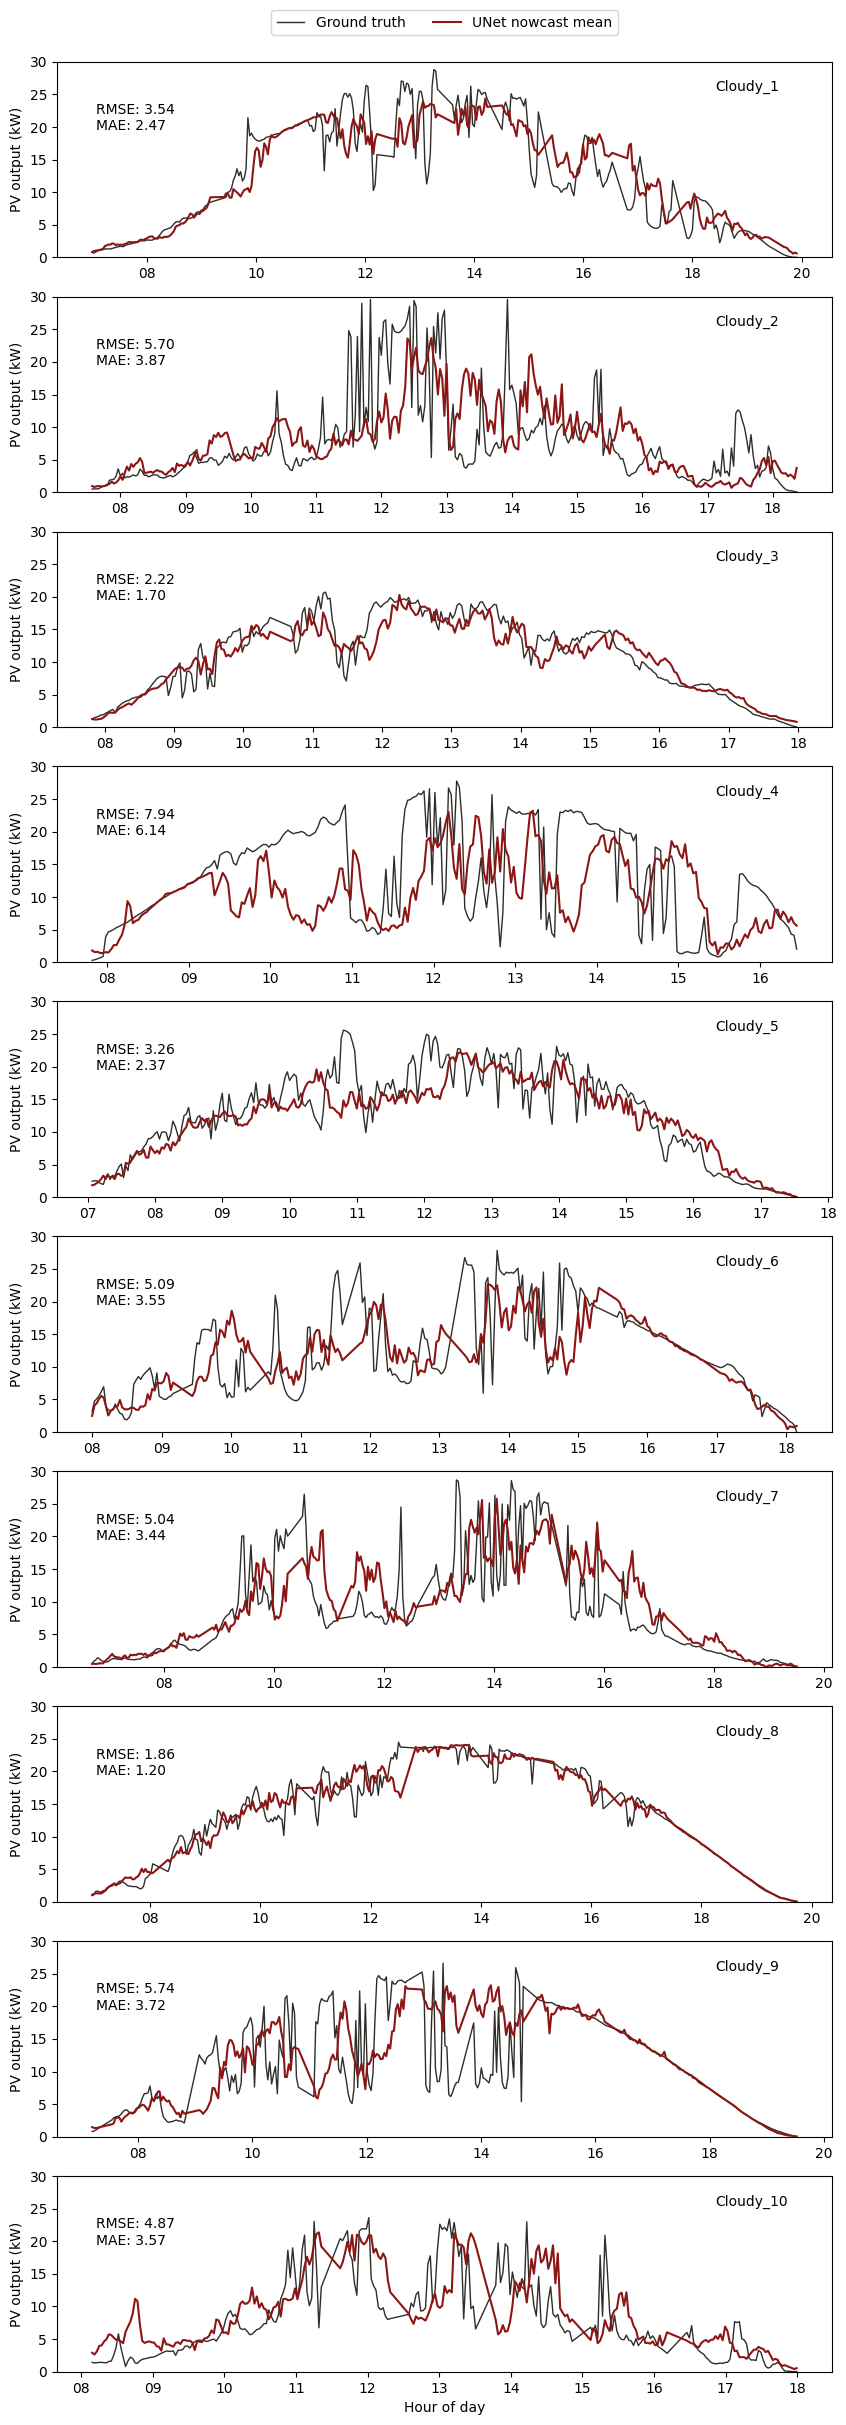

In [14]:
# visualization of forecast predictions
dates_test = np.array(pd.to_datetime(times_test).date)
hours_test = np.array(pd.to_datetime(times_test).time)

f,axarr = plt.subplots(10,1,sharex=False, sharey = True)
xfmt = mdates.DateFormatter('%H')
fmt_date = datetime.date(2000,1,1)

green = '#8AB8A7'
red = '#8C1515'
blue = '#67AFD2'
grey =  '#B6B1A9'
black = '#2E2D29'
red = '#8C1515'
light_blue = '#67AFD2'
dark_blue = '#016895'
blue = '#4298B5'
black = '#2E2D29'
dark_red = '#820000'
light_red = '#B83A4B'

for i,date in enumerate(cloudy_dates_test):
    ax = axarr[i]
    date_mask = (dates_test == date)
    hours_xaxis= [datetime.datetime.combine(fmt_date, hour) for hour in hours_test[date_mask]] 
    
    rmse = np.sqrt(np.mean(np.square((pv_log_test[date_mask]-prediction_ensemble[date_mask]))))
    mae = np.mean(np.abs((pv_log_test[date_mask]-prediction_ensemble[date_mask])))
    
    ax.plot(hours_xaxis, pv_log_test[date_mask], linewidth = 1,color=black, label = 'Ground truth')
    ax.plot(hours_xaxis, prediction_ensemble[date_mask],linewidth = 1.5,label = 'UNet nowcast mean',color=red,markerfacecolor="None")
    #ax.fill_between(hours_xaxis, percent5_prediction[date_mask], percent95_prediction[date_mask], color=light_blue, alpha=0.5, label = '5~95%tile pred.')
    #ax.fill_between(hours_xaxis, percent25_prediction[date_mask], percent75_prediction[date_mask], color=blue, alpha=0.75, label = '25~75%tile pred.')
    ax.set_ylabel('PV output (kW)')
    ax.xaxis.set_major_formatter(xfmt)
    ax.text(0.85,0.85,'Cloudy_'+str(i+1), transform=ax.transAxes)
    #ax.text(0.05,0.65,"RMSE: {0:.2f}\nMAE: {1:.2f}\nFS: {2:.2f}%".format(rmse,mae,fs),transform=ax.transAxes)
    ax.text(0.05,0.65,"RMSE: {0:.2f}\nMAE: {1:.2f}".format(rmse,mae),transform=ax.transAxes)

axarr[0].set_ylim(0, 30)
axarr[0].legend(bbox_to_anchor= [.5,1.3], loc = 'upper center', ncol = 4)
axarr[-1].set_xlabel('Hour of day')

f.set_size_inches(10,30)    
plt.show()

NameError: name 'prediction_ensemble' is not defined

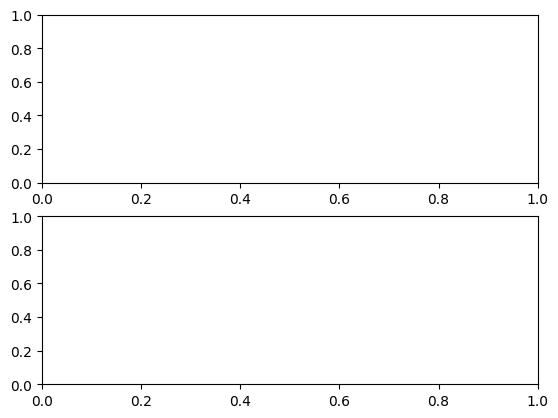

: 

In [ ]:
# visualization of forecast predictions (aligned to target timestamp)
forecast_horizon_min = 15  # must match preprocessing forecast_horizon

times_target = pd.to_datetime(times_test) + pd.Timedelta(minutes=forecast_horizon_min)
dates_test = np.array(times_target.date)
hours_test = np.array(times_target.time)

# keep only cloudy dates that actually exist in this split
available_cloudy_dates = [d for d in cloudy_dates_test if np.any(dates_test == d)]
n = len(available_cloudy_dates)

if n == 0:
    print("No selected cloudy_dates are present in this test split.")
else:
    f, axarr = plt.subplots(n, 1, sharex=False, sharey=True)
    if n == 1:
        axarr = [axarr]

    xfmt = mdates.DateFormatter('%H')
    fmt_date = datetime.date(2000, 1, 1)

    red = '#8C1515'
    black = '#2E2D29'

    for i, date in enumerate(available_cloudy_dates):
        ax = axarr[i]
        date_mask = (dates_test == date)
        hours_xaxis = [datetime.datetime.combine(fmt_date, h) for h in hours_test[date_mask]]

        y_true = pv_log_test[date_mask].reshape(-1)
        y_pred = prediction_ensemble[date_mask].reshape(-1)

        rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
        mae = np.mean(np.abs(y_true - y_pred))

        ax.plot(hours_xaxis, y_true, linewidth=1, color=black, label='Ground truth')
        ax.plot(hours_xaxis, y_pred, linewidth=1.5, color=red, label='VideoMAEv2 prediction')

        ax.set_ylabel('PV output (kW)')
        ax.xaxis.set_major_formatter(xfmt)
        ax.text(0.85, 0.85, f'Cloudy_{i+1}', transform=ax.transAxes)
        ax.text(0.05, 0.65, f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}", transform=ax.transAxes)

    axarr[0].set_ylim(0, 30)
    axarr[0].legend(bbox_to_anchor=[0.5, 1.3], loc='upper center', ncol=2)
    axarr[-1].set_xlabel('Hour of day (target time)')
    f.set_size_inches(10, max(6, 3 * n))
    plt.tight_layout()
    plt.show()